# Model Evaluation

This notebook reviews the trained models stored in `models/builded/`. It compares each Ridge model against the persistence baseline, summarizes the main metrics, and highlights which models are reliable enough to use for prediction.


## Workflow

1. Load the saved metrics and model registry.
2. Add derived MAE improvement indicators.
3. Compare model error against the persistence baseline.
4. Review performance by pollutant, horizon, and station.
5. Identify the strongest models and the models that need attention.


## Setup

Import the libraries used for data handling, plotting, and notebook display.


In [4]:
from pathlib import Path
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display


## Load Evaluation Artifacts

The notebook can be executed from the project root or from inside `models/`. The path check keeps both workflows valid.


In [5]:
ROOT = Path.cwd().resolve()
if not (ROOT / "models" / "builded").exists():
    ROOT = ROOT.parent

BUILD_DIR = ROOT / "models" / "builded"
METRICS_PATH = BUILD_DIR / "metrics.csv"
REGISTRY_PATH = BUILD_DIR / "registry.json"

metrics = pd.read_csv(METRICS_PATH, encoding="utf-8-sig")
registry = json.loads(REGISTRY_PATH.read_text(encoding="utf-8"))

metrics["mae_improvement"] = metrics["baseline_mae"] - metrics["mae"]
metrics["mae_improvement_pct"] = 100 * metrics["mae_improvement"] / metrics["baseline_mae"]
metrics["beats_baseline_mae"] = metrics["beats_baseline_mae"].astype(bool)
optional_metric_columns = [column for column in ["rmse", "r2"] if column in metrics.columns]

print(f"Models evaluated: {len(metrics)}")
print(f"Training timestamp (UTC): {metrics['trained_at_utc'].max()}")
print(f"Models beating baseline: {metrics['beats_baseline_mae'].sum()}/{len(metrics)}")


Models evaluated: 64
Training timestamp (UTC): 2026-06-23T02:31:40+00:00
Models beating baseline: 47/64


## Metric Overview

This table aggregates the metrics by pollutant and forecast horizon. It gives a compact view of how many models beat the baseline and how large the average MAE improvement is.


In [6]:
overview_aggregations = {
    "models": ("model_path", "count"),
    "mae": ("mae", "mean"),
    "baseline_mae": ("baseline_mae", "mean"),
    "beats_baseline": ("beats_baseline_mae", "sum"),
    "mae_improvement_pct": ("mae_improvement_pct", "mean"),
}

for column in optional_metric_columns:
    overview_aggregations[column] = (column, "mean")

overview = (
    metrics
    .groupby(["pollutant", "horizon_hours"], as_index=False)
    .agg(**overview_aggregations)
    .sort_values(["pollutant", "horizon_hours"])
)

display(overview)


,pollutant,horizon_hours,models,mae,baseline_mae,beats_baseline,mae_improvement_pct
0,NO2,8,8,10.634991,14.702779,8,26.047856
1,NO2,24,8,10.255391,10.300460,5,-0.267933
2,O3,8,6,10.338276,10.794038,3,3.026836
3,O3,24,6,11.679987,12.501076,6,6.218521
4,PM10,8,6,2.272754,2.869419,6,19.166880
5,PM10,24,6,6.100654,6.847627,5,6.820577
6,PM2.5,8,6,1.131395,1.521282,6,25.432399
7,PM2.5,24,6,3.318490,3.717356,6,10.146687
8,SO2,8,6,0.430814,0.401286,2,-84.759989
9,SO2,24,6,0.442223,0.315816,0,-105.928770


## Model Error vs Baseline Error

Each point represents one trained model. Points below the diagonal have lower MAE than the persistence baseline.


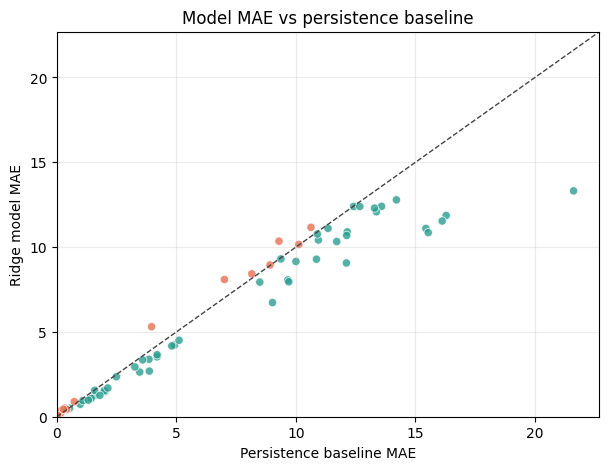

In [7]:
fig, ax = plt.subplots(figsize=(7, 5))
colors = np.where(metrics["beats_baseline_mae"], "#2a9d8f", "#e76f51")
ax.scatter(metrics["baseline_mae"], metrics["mae"], c=colors, alpha=0.8, edgecolor="white", linewidth=0.6)
limit = max(metrics["baseline_mae"].max(), metrics["mae"].max()) * 1.05
ax.plot([0, limit], [0, limit], color="#444", linestyle="--", linewidth=1)
ax.set_xlim(0, limit)
ax.set_ylim(0, limit)
ax.set_xlabel("Persistence baseline MAE")
ax.set_ylabel("Ridge model MAE")
ax.set_title("Model MAE vs persistence baseline")
ax.grid(True, alpha=0.25)
plt.show()


## Improvement Heatmaps

The heatmaps show the percentage MAE improvement by station and pollutant for each forecast horizon. Green means the Ridge model improves the baseline; red means it performs worse.


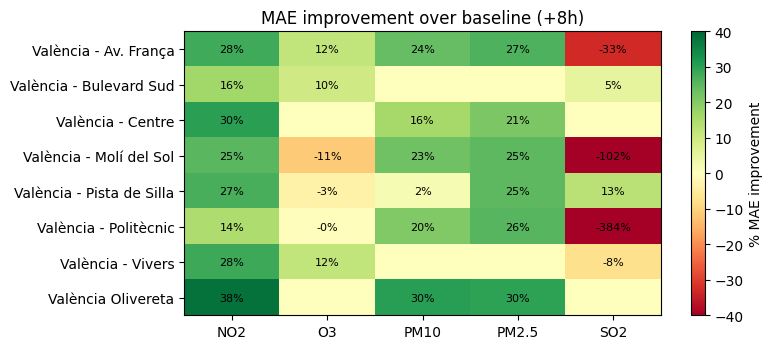

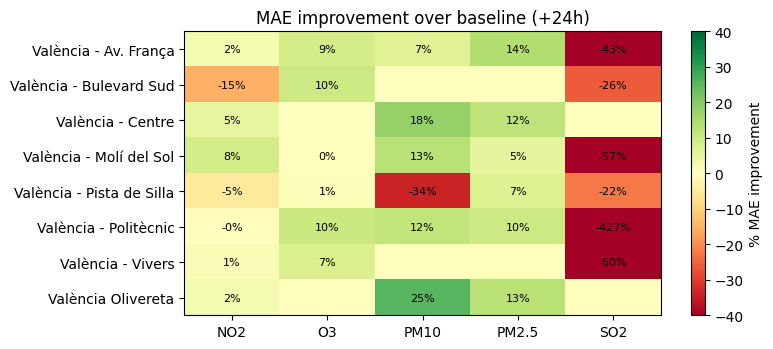

In [8]:
for horizon in sorted(metrics["horizon_hours"].unique()):
    subset = metrics[metrics["horizon_hours"] == horizon]
    pivot = subset.pivot_table(
        index="station",
        columns="pollutant",
        values="mae_improvement_pct",
        aggfunc="mean",
    )

    fig, ax = plt.subplots(figsize=(8, max(3.5, 0.45 * len(pivot))))
    image = ax.imshow(pivot.fillna(0), cmap="RdYlGn", vmin=-40, vmax=40, aspect="auto")
    ax.set_xticks(range(len(pivot.columns)), pivot.columns)
    ax.set_yticks(range(len(pivot.index)), pivot.index)
    ax.set_title(f"MAE improvement over baseline (+{horizon}h)")

    for i in range(len(pivot.index)):
        for j in range(len(pivot.columns)):
            value = pivot.iloc[i, j]
            label = "" if pd.isna(value) else f"{value:.0f}%"
            ax.text(j, i, label, ha="center", va="center", fontsize=8)

    fig.colorbar(image, ax=ax, label="% MAE improvement")
    plt.tight_layout()
    plt.show()


## Station-Level Summary

This chart ranks stations by average MAE improvement. It is useful for spotting stations where the model family is consistently strong or weak.


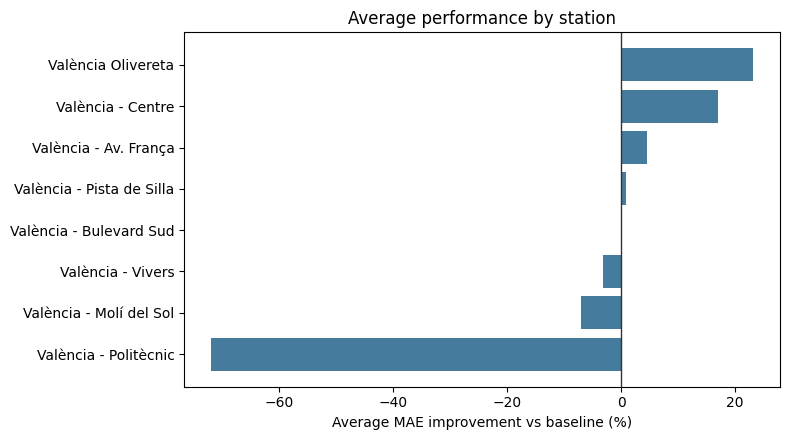

,station,models,beats,avg_improvement_pct
5,València - Politècnic,10,6,-71.953340
3,València - Molí del Sol,10,7,-7.046477
6,València - Vivers,6,4,-3.141406
1,València - Bulevard Sud,6,4,-0.019634
4,València - Pista de Silla,10,6,0.952392
0,València - Av. França,10,8,4.558149
2,València - Centre,6,6,16.964576
7,València Olivereta,6,6,23.174963


In [9]:
station_aggregations = {
    "models": ("model_path", "count"),
    "beats": ("beats_baseline_mae", "sum"),
    "avg_improvement_pct": ("mae_improvement_pct", "mean"),
}

if "r2" in metrics.columns:
    station_aggregations["avg_r2"] = ("r2", "mean")

by_station = (
    metrics
    .groupby("station", as_index=False)
    .agg(**station_aggregations)
    .sort_values("avg_improvement_pct")
)

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.barh(by_station["station"], by_station["avg_improvement_pct"], color="#457b9d")
ax.axvline(0, color="#333", linewidth=1)
ax.set_xlabel("Average MAE improvement vs baseline (%)")
ax.set_title("Average performance by station")
plt.tight_layout()
plt.show()

display(by_station)


## Best Models and Watchlist

The first table lists the strongest models by MAE improvement. The second table lists models that should be reviewed before being used as the main prediction source.


In [10]:
best = metrics.sort_values("mae_improvement_pct", ascending=False).head(10)
worst = metrics.sort_values("mae_improvement_pct", ascending=True).head(10)
ranking_columns = ["station", "pollutant", "horizon_hours", "mae", "baseline_mae", "mae_improvement_pct"]

if "r2" in metrics.columns:
    ranking_columns.append("r2")

ranking_columns.append("model_path")

print("Best models")
display(best[ranking_columns])

print("Models to monitor")
display(worst[ranking_columns])


Best models


,station,pollutant,horizon_hours,mae,baseline_mae,mae_improvement_pct,model_path
58,València Olivereta,NO2,8,13.312805,21.615721,38.411466,models/builded/model__valencia_olivereta__no2_...
60,València Olivereta,PM10,8,2.691675,3.867209,30.397490,models/builded/model__valencia_olivereta__pm10...
16,València - Centre,NO2,8,10.852006,15.534985,30.144728,models/builded/model__valencia_centre__no2__h0...
62,València Olivereta,PM2.5,8,1.261146,1.797093,29.822979,models/builded/model__valencia_olivereta__pm2_...
54,València - Vivers,NO2,8,11.538224,16.119670,28.421465,models/builded/model__valencia_vivers__no2__h0...
2,València - Av. França,NO2,8,11.098789,15.437037,28.102852,models/builded/model__valencia_av_franca__no2_...
34,València - Pista de Silla,NO2,8,11.862521,16.284712,27.155477,models/builded/model__valencia_pista_de_silla_...
8,València - Av. França,PM2.5,8,1.479993,2.014830,26.544991,models/builded/model__valencia_av_franca__pm2_...
50,València - Politècnic,PM2.5,8,0.977393,1.313385,25.582188,models/builded/model__valencia_politecnic__pm2...
61,València Olivereta,PM10,24,6.728760,9.018889,25.392577,models/builded/model__valencia_olivereta__pm10...


Models to monitor


,station,pollutant,horizon_hours,mae,baseline_mae,mae_improvement_pct,model_path
43,València - Politècnic,SO2,24,0.092870,0.017621,-427.039615,models/builded/model__valencia_politecnic__so2...
42,València - Politècnic,SO2,8,0.083396,0.017217,-384.393283,models/builded/model__valencia_politecnic__so2...
22,València - Molí del Sol,SO2,8,0.382095,0.189415,-101.723847,models/builded/model__valencia_moli_del_sol__s...
53,València - Vivers,SO2,24,0.438155,0.273876,-59.982673,models/builded/model__valencia_vivers__so2__h2...
23,València - Molí del Sol,SO2,24,0.509467,0.324638,-56.934121,models/builded/model__valencia_moli_del_sol__s...
1,València - Av. França,SO2,24,0.239974,0.167401,-43.352689,models/builded/model__valencia_av_franca__so2_...
39,València - Pista de Silla,PM10,24,5.304081,3.960482,-33.925130,models/builded/model__valencia_pista_de_silla_...
0,València - Av. França,SO2,8,0.230969,0.173601,-33.045901,models/builded/model__valencia_av_franca__so2_...
11,València - Bulevard Sud,SO2,24,0.483061,0.383178,-26.067180,models/builded/model__valencia_bulevard_sud__s...
33,València - Pista de Silla,SO2,24,0.889813,0.728183,-22.196345,models/builded/model__valencia_pista_de_silla_...


## Reading Guide

- A point below the diagonal means the model improves the persistence baseline.
- In the heatmaps, green means Ridge reduces MAE against the baseline; red means it performs worse.
- Watchlist models do not necessarily need to be deleted, but they should not be published as the primary prediction if they lose against persistence.
